# Debt simulation
The agents exchange a fixed amount of money and can incur debt up to a maximum limit.

In [1]:
import importlib
import functions as func
import matplotlib.pyplot as plt
import numpy as np

func = importlib.reload(func)

In [2]:
N = 1000
M = 3e4
steps = 10e7
md = 50


agents = func.simulate_with_debt_shifted(
    N=N,
    M=M,
    steps=steps,
    md=md,
    transaction_type='constant'
)

print(f"Shape: {agents.shape}")
print(f"Total money: {agents.sum():.2f}")
print(f"Minimum: {agents.min():.2f}")
print(f"Maximum: {agents.max():.2f}")
print("First 10 agents:", agents[:10])

Shape: (1000,)
Total money: 30000.00
Minimum: -50.00
Maximum: 563.00
First 10 agents: [ -3.   6.  33. -49.  44. -25.  65. -33. 222.  -3.]


In [3]:
print("Agents:", agents[:])

Agents: [ -3.   6.  33. -49.  44. -25.  65. -33. 222.  -3. -48. -19.  60.  11.
 -34.  17.  15. 352.  38.  99. 101. 186. -22. -18. -42.  20.  79.  -4.
  17. 252.   2. -36. 177. -39. -17. -44. -41. 106.  15. -42.  51. -43.
  17. 143.  25.  93.  -8. -31.  42.  95. -42.  27.  41.  11. -20.  18.
  96. -16. -22. -33. -19. -39. -46. 127. -10.  15.  57. 106.  56.  57.
  32. -39.  -9. -36. -26.  99. -37.  -6. -17. -26.  31. -46. -17.   4.
  69. -24. -49. -11. -30. 412.  23.   4.  25.  72. 110.   6. -26.  72.
  -4.  13. -44. -42. -50. -27. -44. -39.  58. -49. 181. -38. 222. -38.
 -28. 168. -47.  28. -19.  80. -29.  45. -10.   2. -28.  -9. 156. 204.
  34. -34.  73. -13. -19.  -7. 276. -27. -10.  99. -44.  14. -40.  85.
 -34.  -2.  11. 212.  82. 473. 318. 213.  10. -37.  74. -35.  75.  -5.
  10.  -9. -47.  53. -49. -41. 103. 122. -34.  18. -23.   5. -40. 282.
 -19.  31. -41. 126.  24.  44.   2. 144.   0.  25.  22. -13.  25.   3.
 -40. 181.  99.  15.  37. -49.   8.   3. -46.  55.  58. 213. 137.  26

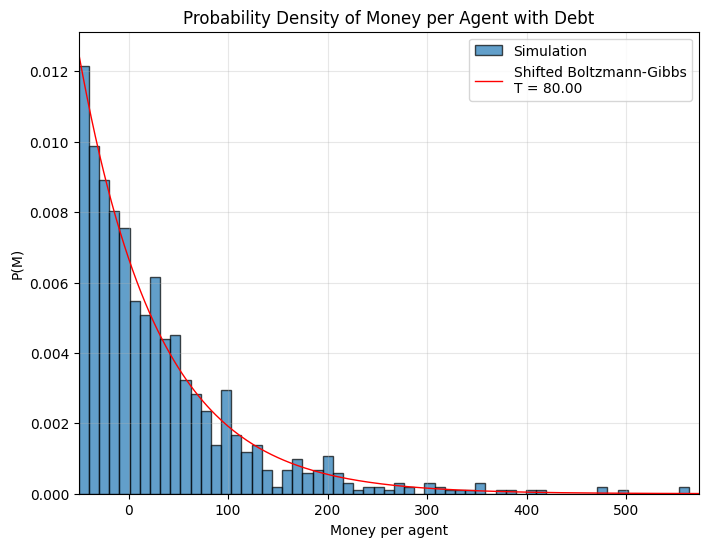

In [11]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

T_debt = M / N + md

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    agents,
    bins=60,
    density=True,
    alpha=0.7,
    edgecolor="black",
    label="Simulation"
)

x_fit = np.linspace(-md, agents.max() + 10, 300)
y_fit = (1 / T_debt) * np.exp(-(x_fit + md) / T_debt)

ax.plot(
    x_fit,
    y_fit,
    "r-",
    linewidth=1,
    label=f"Shifted Boltzmann-Gibbs\nT = {T_debt:.2f}"
)

ax.set_xlabel("Money per agent")
ax.set_ylabel("P(M)")
ax.set_title("Probability Density of Money per Agent with Debt")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(-md, agents.max() + 10)
plt.show()

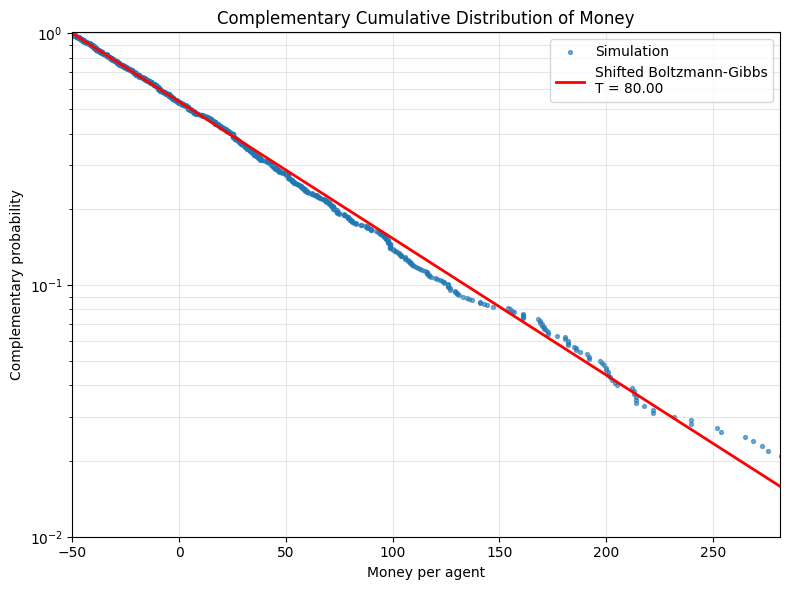

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

sorted_agents = np.sort(agents)
probability = 1 - np.arange(1, N + 1) / N

ax.scatter(
    sorted_agents,
    probability,
    s=8,
    alpha=0.6,
    label="Simulation"
)

ax.plot(
    x_fit,
    np.exp(-(x_fit + md) / T_debt),
    "r-",
    linewidth=2,
    label=f"Shifted Boltzmann-Gibbs\nT = {T_debt:.2f}"
)

ax.set_yscale("log")
ax.set_xlabel("Money per agent")
ax.set_ylabel("Complementary probability")
ax.set_title("Complementary Cumulative Distribution of Money")
ax.legend()
ax.grid(which="both", alpha=0.3)
ax.set_xlim(-md, agents.max() / 2)
ax.set_ylim(1e-2, 1.01)

plt.tight_layout()
plt.show()

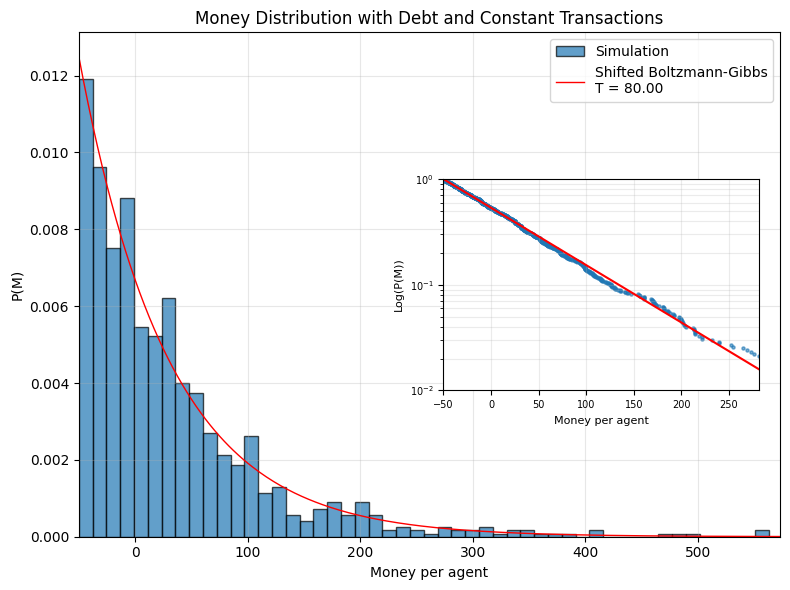

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

# First plot: histogram and shifted Boltzmann-Gibbs distribution
ax.hist(
    agents,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor="black",
    label="Simulation"
)

ax.plot(
    x_fit,
    y_fit,
    "r-",
    linewidth=1,
    label=f"Shifted Boltzmann-Gibbs\nT = {T_debt:.2f}"
)

ax.set_xlabel("Money per agent")
ax.set_ylabel("P(M)")
ax.set_title("Money Distribution with Debt and Constant Transactions")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
ax.set_xlim(-md, agents.max() + 10)

# Second plot as a small overlay, centered vertically and shifted right
inset = ax.inset_axes([0.52, 0.29, 0.45, 0.42])

inset.scatter(
    sorted_agents,
    probability,
    s=5,
    alpha=0.6,
    color="tab:blue"
)

inset.plot(
    x_fit,
    np.exp(-(x_fit + md) / T_debt),
    "r-",
    linewidth=1.5
)

inset.set_yscale("log")
inset.set_xlim(-md, agents.max() / 2)
inset.set_ylim(1e-2, 1.01)
inset.set_xlabel("Money per agent", fontsize=8)
inset.set_ylabel("Log(P(M))", fontsize=8)
inset.tick_params(axis="both", labelsize=7)
inset.grid(which="both", alpha=0.25)

plt.tight_layout()
plt.show()